# 01b Feature Assessment and CORE5 Design

Aim of this notebook: assess candidate behavioural features using fitting accounts only and freeze the five-dimensional CORE5 representation used downstream.

The strict feature-orientation reference is the dollar-suffix machine proxy versus the U-named user proxy.


## 0. Configuration


In [1]:
from pathlib import Path
import hashlib
import json

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, roc_auc_score


FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
BUILD_META_PATH = Path("static_features_v2/feature_build_meta.json")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")

OUT = Path("eda_outputs_01b_fit_features_core5")
OUT.mkdir(exist_ok=True)

REPRESENTATION_META_PATH = OUT / "representation_meta.json"
MANUSCRIPT_OUT = OUT / "manuscript_ready"
MANUSCRIPT_OUT.mkdir(exist_ok=True)

WIN_PRIMARY = 0

CANDIDATE_FEATURES = [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
    "active_days",
    "ticket_frac",
    "logon_miss_frac",
]

CORE5 = [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]

DIAGNOSTIC_FEATURES = [
    "active_days",
    "ticket_frac",
    "logon_miss_frac",
]

# Candidate features by behavioural construct
FEATURE_GROUPS = {
    "periodicity": ["period_strength"],
    "spacing_regularity": ["iat_cv"],
    "activity_scale": ["log_volume"],
    "destination_structure": ["log_fanout"],
    "enterprise_timing": ["quiet_frac"],
    "persistence": ["active_days"],
    "protocol_context": [
        "ticket_frac",
        "logon_miss_frac",
    ],
}

PRIMARY_POSITIVE = "$ machine proxy"
PRIMARY_NEGATIVE = "U-named user proxy"

print("Configuration ready.")
print("CORE5:", CORE5)


Configuration ready.
CORE5: ['period_strength', 'iat_cv', 'log_volume', 'log_fanout', 'quiet_frac']


## 1. Load the feature table and fitting partition

The canonical feature table from notebook 01 is verified against its saved hash, then restricted to accounts in the fitting partition before feature assessment.


In [2]:
def file_sha256(path):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


for required in [FEATURE_PATH, BUILD_META_PATH, ACCOUNT_SPLIT_PATH]:
    if not required.exists():
        raise FileNotFoundError(f"Missing required input: {required}")

build_meta = json.loads(BUILD_META_PATH.read_text())
expected_hash = build_meta.get("output_hashes", {}).get("feat_final")
actual_hash = file_sha256(FEATURE_PATH)

if expected_hash != actual_hash:
    raise RuntimeError("Feature table does not match notebook-01 provenance.")

con = duckdb.connect()
feat = con.execute(
    f"SELECT * FROM '{FEATURE_PATH.as_posix()}'"
).df()
con.close()

required_cols = ["u", "win"] + CANDIDATE_FEATURES
missing = [c for c in required_cols if c not in feat.columns]
if missing:
    raise RuntimeError(f"Feature table missing columns: {missing}")

feat["u"] = feat["u"].astype(str)

if feat.duplicated(["u", "win"]).any():
    raise RuntimeError("Duplicate (u, win) rows in feature table.")


# Fit-only development sample
split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())
if set(split_obj) != {"fit", "calibration", "test"}:
    raise RuntimeError("Unexpected account-split structure.")

fit_a = set(map(str, split_obj["fit"]))
cal_a = set(map(str, split_obj["calibration"]))
test_a = set(map(str, split_obj["test"]))

assert fit_a.isdisjoint(cal_a)
assert fit_a.isdisjoint(test_a)
assert cal_a.isdisjoint(test_a)

if set(feat["u"]) != (fit_a | cal_a | test_a):
    raise RuntimeError("Feature-table account universe does not match the account split.")

fit_feat = feat.loc[feat["u"].isin(fit_a)].copy()
f0 = fit_feat.loc[fit_feat["win"] == WIN_PRIMARY].copy()

assert set(fit_feat["u"]).isdisjoint(cal_a)
assert set(fit_feat["u"]).isdisjoint(test_a)

print(f"Feature table        : {feat.shape}")
print(f"Fit accounts         : {len(fit_a):,}")
print(f"Fit account-windows  : {len(fit_feat):,}")
print(f"Fit window-0 rows    : {len(f0):,}")


Feature table        : (104147, 12)
Fit accounts         : 17,734
Fit account-windows  : 62,310
Fit window-0 rows    : 15,636


## 2. Define the strict weak-proxy contrast

Feature direction is assessed only with dollar-suffix machine-proxy accounts and U-named user-proxy accounts. Other account types are not used in these metrics.


In [3]:
def strict_proxy(u):
    s = str(u).upper()
    if "$@" in s or s.endswith("$"):
        return "$ machine proxy"
    if s.startswith("U"):
        return "U-named user proxy"
    return "other"


fit_feat["account_type"] = fit_feat["u"].map(strict_proxy)
f0["account_type"] = f0["u"].map(strict_proxy)

proxy_counts = (
    f0["account_type"]
    .value_counts()
    .reindex([PRIMARY_NEGATIVE, PRIMARY_POSITIVE, "other"])
)

print(proxy_counts.dropna().to_string())


account_type
U-named user proxy    5665
$ machine proxy       7118
other                 2853


## 3. Feature availability

Check missingness for each candidate feature across fitting windows. `period_strength` can be missing because it requires at least 50 events.


In [4]:
missing_rows = []

for w, sub in fit_feat.groupby("win"):
    for c in CANDIDATE_FEATURES:
        missing_rows.append({
            "win": int(w),
            "feature": c,
            "n_rows": len(sub),
            "n_non_missing": int(sub[c].notna().sum()),
            "n_missing": int(sub[c].isna().sum()),
            "missing_frac": float(sub[c].isna().mean()),
            "median": (
                float(sub[c].median(skipna=True))
                if sub[c].notna().any()
                else np.nan
            ),
        })

missing_by_window = pd.DataFrame(missing_rows)

missing_primary = (
    missing_by_window.loc[missing_by_window["win"] == WIN_PRIMARY]
    .sort_values("missing_frac", ascending=False)
    .reset_index(drop=True)
)

print(missing_primary.to_string(index=False))

missing_by_window.to_csv(
    OUT / "01_fit_feature_missingness_by_window.csv",
    index=False,
)


 win         feature  n_rows  n_non_missing  n_missing  missing_frac    median
   0 period_strength   15636          14808        828      0.052955 37.098959
   0          iat_cv   15636          15636          0      0.000000  2.815523
   0      log_volume   15636          15636          0      0.000000  3.289477
   0      log_fanout   15636          15636          0      0.000000  1.113943
   0      quiet_frac   15636          15636          0      0.000000  0.266462
   0     active_days   15636          15636          0      0.000000 12.000000
   0     ticket_frac   15636          15636          0      0.000000  0.101920
   0 logon_miss_frac   15636          15636          0      0.000000  0.104832


## 4. Candidate-feature distributions

Compare the strict proxy groups across all eight candidate features in fitting window 0. These boxplots are retained as an additional notebook diagnostic; they are not a dissertation figure. Outlier markers are hidden for visual clarity.


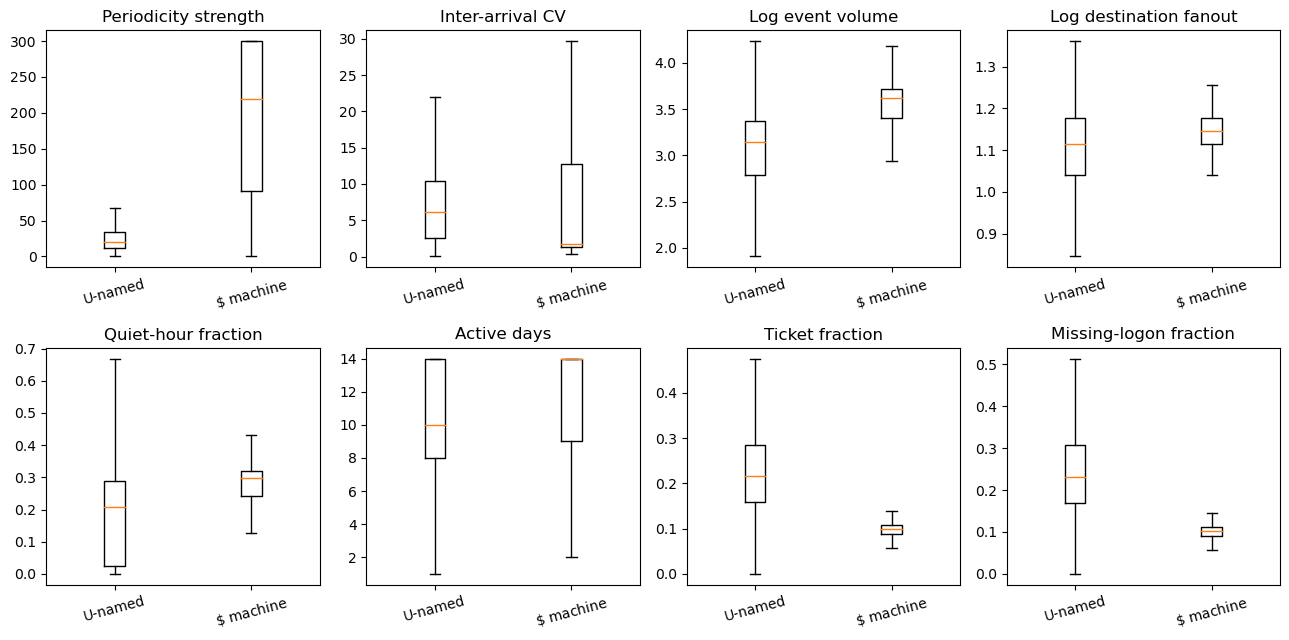

In [5]:
strict_plot = f0.loc[
    f0["account_type"].isin([
        PRIMARY_NEGATIVE,
        PRIMARY_POSITIVE,
    ])
].copy()

FEATURE_DISPLAY = {
    "period_strength": "Periodicity strength",
    "iat_cv": "Inter-arrival CV",
    "log_volume": "Log event volume",
    "log_fanout": "Log destination fanout",
    "quiet_frac": "Quiet-hour fraction",
    "active_days": "Active days",
    "ticket_frac": "Ticket fraction",
    "logon_miss_frac": "Missing-logon fraction",
}

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
axes = axes.ravel()

for ax, feature in zip(axes, CANDIDATE_FEATURES):
    values = [
        strict_plot.loc[
            strict_plot["account_type"] == group,
            feature,
        ].dropna().astype(float).to_numpy()
        for group in [PRIMARY_NEGATIVE, PRIMARY_POSITIVE]
    ]

    ax.boxplot(
        values,
        labels=["U-named", r"$\$$ machine"],
        showfliers=False,
    )
    ax.set_title(FEATURE_DISPLAY[feature])
    ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(
    OUT / "02_candidate_feature_boxplots_strict_proxy.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 5. Feature redundancy

Use pairwise Spearman correlations in fitting window 0 to assess overlap among the eight candidates and within the retained CORE5 dimensions.


In [6]:
corr_all = f0[CANDIDATE_FEATURES].corr(method="spearman")
corr_core5 = f0[CORE5].corr(method="spearman")

corr_all.to_csv(OUT / "04_candidate_feature_correlation.csv")
corr_core5.to_csv(OUT / "04_core5_correlation.csv")

print("=== Candidate-feature Spearman correlation ===")
print(corr_all.round(3).to_string())

print("\n=== CORE5 Spearman correlation ===")
print(corr_core5.round(3).to_string())


=== Candidate-feature Spearman correlation ===
                 period_strength  iat_cv  log_volume  log_fanout  quiet_frac  active_days  ticket_frac  logon_miss_frac
period_strength            1.000  -0.178       0.847       0.404       0.588        0.432       -0.092           -0.097
iat_cv                    -0.178   1.000      -0.082       0.322      -0.532       -0.566        0.361            0.364
log_volume                 0.847  -0.082       1.000       0.607       0.549        0.579        0.057            0.044
log_fanout                 0.404   0.322       0.607       1.000       0.083        0.121        0.416            0.407
quiet_frac                 0.588  -0.532       0.549       0.083       1.000        0.629       -0.119           -0.133
active_days                0.432  -0.566       0.579       0.121       0.629        1.000       -0.114           -0.124
ticket_frac               -0.092   0.361       0.057       0.416      -0.119       -0.114        1.000           

## 6. Single-feature proxy alignment

In fitting window 0, calculate average precision for each feature in its original and sign-reversed direction. The higher-AP direction is retained so that larger oriented values correspond to the machine-proxy side.


In [7]:
def proxy_alignment_table(df, features):
    sub = df[
        df["account_type"].isin([
            PRIMARY_POSITIVE,
            PRIMARY_NEGATIVE,
        ])
    ].copy()

    sub["y"] = (sub["account_type"] == PRIMARY_POSITIVE).astype(int)

    rows = []

    for c in features:
        d = sub[[c, "y"]].dropna()
        if len(d) < 50 or d["y"].nunique() != 2:
            continue

        x = d[c].astype(float).to_numpy()
        y = d["y"].to_numpy()
        prevalence = float(y.mean())

        ap_pos = average_precision_score(y, x)
        ap_neg = average_precision_score(y, -x)

        roc_pos = roc_auc_score(y, x)
        roc_neg = roc_auc_score(y, -x)

        if ap_neg > ap_pos:
            chosen_sign = -1
            direction = f"lower => {PRIMARY_POSITIVE}"
            auprc = ap_neg
            roc = roc_neg
        else:
            chosen_sign = 1
            direction = f"higher => {PRIMARY_POSITIVE}"
            auprc = ap_pos
            roc = roc_pos

        rows.append({
            "feature": c,
            "direction_fit_win0": direction,
            "chosen_sign": chosen_sign,
            "n": len(d),
            "positive_prevalence": prevalence,
            "AUPRC": auprc,
            "AUPRC_lift_vs_prevalence": auprc / prevalence,
            "ROC_AUC": roc,
            "AUPRC_as_is": ap_pos,
            "AUPRC_reversed": ap_neg,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["AUPRC_lift_vs_prevalence", "ROC_AUC"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


primary_alignment = proxy_alignment_table(
    f0,
    CANDIDATE_FEATURES,
)

print(primary_alignment.to_string(index=False))

primary_alignment.to_csv(
    OUT / "05_primary_single_feature_alignment_fit_win0.csv",
    index=False,
)


        feature        direction_fit_win0  chosen_sign     n  positive_prevalence    AUPRC  AUPRC_lift_vs_prevalence  ROC_AUC  AUPRC_as_is  AUPRC_reversed
period_strength higher => $ machine proxy            1 12487             0.567390 0.876790                  1.545304 0.876317     0.876790        0.395724
     log_volume higher => $ machine proxy            1 12783             0.556833 0.773302                  1.388750 0.793527     0.773302        0.398474
         iat_cv  lower => $ machine proxy           -1 12783             0.556833 0.764273                  1.372535 0.649536     0.531635        0.764273
logon_miss_frac  lower => $ machine proxy           -1 12783             0.556833 0.759237                  1.363491 0.856005     0.380591        0.759237
    ticket_frac  lower => $ machine proxy           -1 12783             0.556833 0.746619                  1.340830 0.845272     0.383315        0.746619
     quiet_frac higher => $ machine proxy            1 12783          

## 7. Cross-window consistency

Keep the feature directions selected in fitting window 0 fixed, then recompute AP and AUROC in fitting windows 1–3.


In [8]:
direction_map = (
    primary_alignment
    .set_index("feature")["chosen_sign"]
    .to_dict()
)

stability_rows = []

for w in sorted(fit_feat["win"].astype(int).unique()):
    sub = fit_feat[
        fit_feat["account_type"].isin([
            PRIMARY_POSITIVE,
            PRIMARY_NEGATIVE,
        ])
        & (fit_feat["win"] == w)
    ].copy()

    sub["y"] = (sub["account_type"] == PRIMARY_POSITIVE).astype(int)

    for c in CANDIDATE_FEATURES:
        d = sub[[c, "y"]].dropna()

        if len(d) < 50 or d["y"].nunique() != 2:
            continue

        y = d["y"].to_numpy()
        x = direction_map[c] * d[c].astype(float).to_numpy()

        prevalence = float(y.mean())
        auprc = average_precision_score(y, x)
        roc = roc_auc_score(y, x)

        stability_rows.append({
            "win": int(w),
            "feature": c,
            "n": len(d),
            "positive_prevalence": prevalence,
            "AUPRC_fixed_direction": auprc,
            "AUPRC_lift_vs_prevalence": auprc / prevalence,
            "ROC_AUC_fixed_direction": roc,
        })

stability = pd.DataFrame(stability_rows)

stability_summary = (
    stability.groupby("feature", as_index=False)
    .agg(
        n_windows=("win", "nunique"),
        AUPRC_min=("AUPRC_fixed_direction", "min"),
        AUPRC_median=("AUPRC_fixed_direction", "median"),
        AUPRC_max=("AUPRC_fixed_direction", "max"),
        ROC_min=("ROC_AUC_fixed_direction", "min"),
        ROC_median=("ROC_AUC_fixed_direction", "median"),
        ROC_max=("ROC_AUC_fixed_direction", "max"),
        lift_min=("AUPRC_lift_vs_prevalence", "min"),
        lift_median=("AUPRC_lift_vs_prevalence", "median"),
    )
    .sort_values(
        ["lift_median", "ROC_median"],
        ascending=False,
    )
)

print(stability_summary.to_string(index=False))

stability.to_csv(
    OUT / "07_primary_alignment_by_fit_window.csv",
    index=False,
)

stability_summary.to_csv(
    OUT / "07_primary_alignment_stability_summary.csv",
    index=False,
)


        feature  n_windows  AUPRC_min  AUPRC_median  AUPRC_max  ROC_min  ROC_median  ROC_max  lift_min  lift_median
period_strength          4   0.861137      0.871891   0.876906 0.854486    0.866311 0.876317  1.488444     1.513091
     log_volume          4   0.762896      0.772689   0.782307 0.762636    0.778122 0.793527  1.340089     1.373699
         iat_cv          4   0.764247      0.767790   0.788435 0.640933    0.651234 0.654035  1.342462     1.371963
logon_miss_frac          4   0.757014      0.761012   0.768917 0.840318    0.852634 0.856005  1.329756     1.353678
    ticket_frac          4   0.744886      0.749221   0.756751 0.829387    0.842808 0.845272  1.308453     1.333242
     quiet_frac          4   0.685484      0.700462   0.709823 0.699014    0.702045 0.705481  1.231039     1.237905
    active_days          4   0.638221      0.640402   0.656269 0.585889    0.605522 0.610001  1.121088     1.144354
     log_fanout          4   0.500343      0.542379   0.600161 0.378897 

## 8. Freeze CORE5

CORE5 retains periodicity strength, inter-arrival regularity, activity scale, destination interaction structure and enterprise-relative quiet-hour activity. `active_days` is excluded as a coarse persistence measure, while `ticket_frac` and `logon_miss_frac` are excluded as protocol-specific and nearly redundant record-composition measures.


In [9]:
rationale = {
    "period_strength": "Retained as a direct temporal-periodicity construct.",
    "iat_cv": "Retained to represent event-spacing regularity.",
    "log_volume": "Retained to represent overall activity intensity.",
    "log_fanout": "Retained as a distinct destination interaction-structure construct.",
    "quiet_frac": "Retained to provide enterprise-relative temporal context.",
    "active_days": "Excluded as a coarse persistence measure that overlapped with timing and activity scale.",
    "ticket_frac": "Excluded as protocol-specific and nearly redundant with missing-logon fraction.",
    "logon_miss_frac": "Excluded as protocol-specific and nearly redundant with ticket fraction.",
}

primary_indexed = primary_alignment.set_index("feature")
stability_indexed = stability_summary.set_index("feature")

selection_rows = []
for c in CANDIDATE_FEATURES:
    selection_rows.append({
        "feature": c,
        "in_core5": c in CORE5,
        "fit_win0_direction": primary_indexed.loc[c, "direction_fit_win0"],
        "fit_win0_AUPRC": primary_indexed.loc[c, "AUPRC"],
        "fit_win0_AUPRC_lift": primary_indexed.loc[c, "AUPRC_lift_vs_prevalence"],
        "fit_win0_ROC_AUC": primary_indexed.loc[c, "ROC_AUC"],
        "cross_window_AUPRC_median": stability_indexed.loc[c, "AUPRC_median"],
        "cross_window_ROC_median": stability_indexed.loc[c, "ROC_median"],
        "rationale": rationale[c],
    })

selection_evidence = pd.DataFrame(selection_rows)
selection_evidence.to_csv(
    OUT / "08_core5_representation_evidence.csv",
    index=False,
)

representation_meta = {
    "pipeline_stage": "01b_fit_only_feature_assessment_core5_freeze",
    "representation_name": "CORE5",
    "core5_generic": CORE5,
    "diagnostic_features": DIAGNOSTIC_FEATURES,
    "feature_sha256": actual_hash,
    "account_split_sha256": file_sha256(ACCOUNT_SPLIT_PATH),
    "selection_principle": (
        "parsimonious coverage of complementary behavioural constructs; "
        "not exhaustive subset search and not maximisation of weak-proxy AUPRC"
    ),
    "quiet_frac_role": "enterprise-adaptive temporal context",
    "calibration_evaluated": False,
    "test_evaluated": False,
    "outputs": {
        "selection_evidence": str(OUT / "08_core5_representation_evidence.csv"),
        "candidate_boxplots": str(OUT / "02_candidate_feature_boxplots_strict_proxy.png"),
        "candidate_correlation": str(MANUSCRIPT_OUT / "Figure_08_candidate_feature_correlation.csv"),
        "core5_ecdf": str(MANUSCRIPT_OUT / "Figure_07_core5_strict_proxy_ecdf.png"),
        "candidate_diagnostics_table": str(MANUSCRIPT_OUT / "Table_06_candidate_feature_diagnostics.csv"),
        "fixed_orientation_table": str(MANUSCRIPT_OUT / "Table_07_fixed_feature_orientation.csv"),
    },
}

REPRESENTATION_META_PATH.write_text(
    json.dumps(representation_meta, indent=2)
)

print("Frozen CORE5:", CORE5)
print("Representation metadata:", REPRESENTATION_META_PATH)


Frozen CORE5: ['period_strength', 'iat_cv', 'log_volume', 'log_fanout', 'quiet_frac']
Representation metadata: eda_outputs_01b_fit_features_core5/representation_meta.json


## 9. Dissertation and supplementary outputs

Reproduce the current dissertation outputs from feature assessment:

- Supplementary Figure 7: strict-proxy ECDFs for the five CORE5 features;
- Supplementary Figure 8: candidate-feature Spearman correlations;
- Supplementary Table 6: candidate-feature diagnostics and CORE5 inclusion decisions;
- Supplementary Table 7: fixed-orientation AP and AUROC across fitting windows.

The eight-feature boxplots above are an additional notebook diagnostic only.


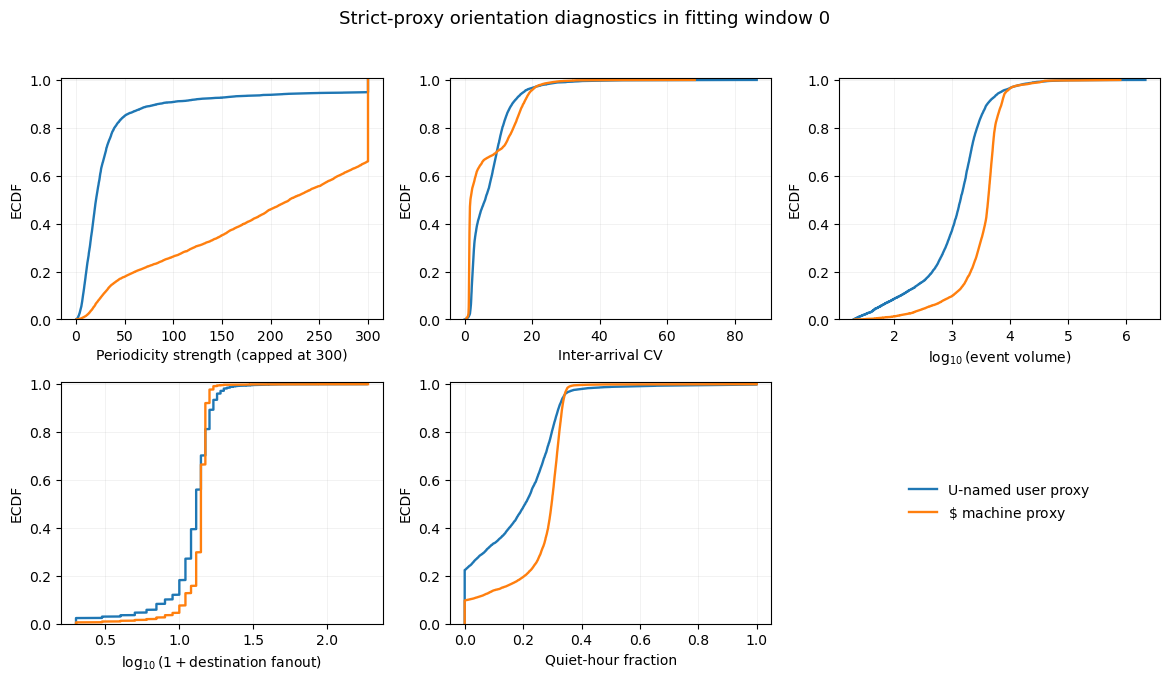

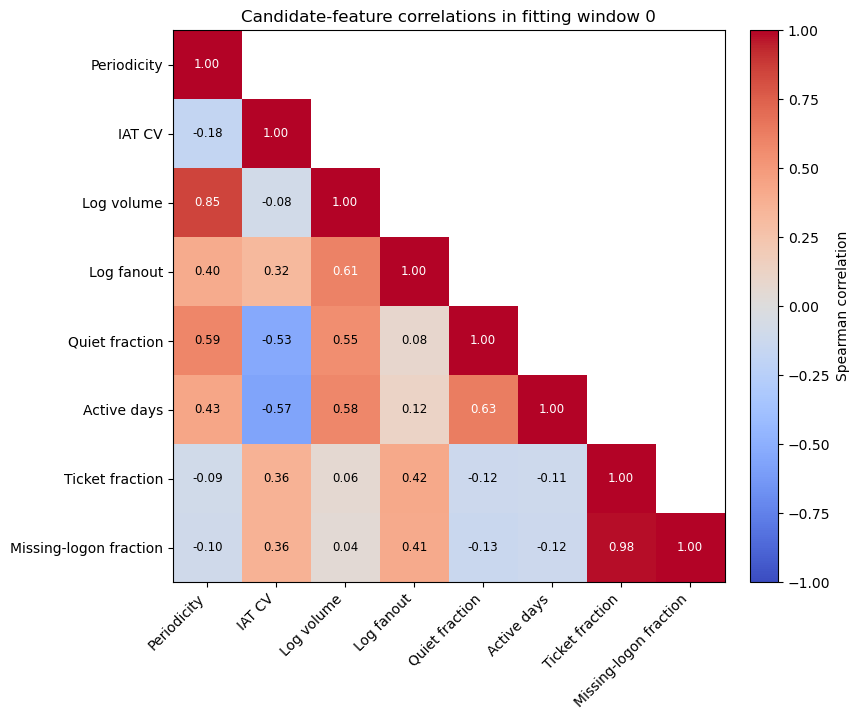

Supplementary Figure 7: eda_outputs_01b_fit_features_core5/manuscript_ready/Figure_07_core5_strict_proxy_ecdf.png
Supplementary Figure 8: eda_outputs_01b_fit_features_core5/manuscript_ready/Figure_08_candidate_feature_correlation.png
Supplementary Table 6: eda_outputs_01b_fit_features_core5/manuscript_ready/Table_06_candidate_feature_diagnostics.csv
Supplementary Table 7: eda_outputs_01b_fit_features_core5/manuscript_ready/Table_07_fixed_feature_orientation.csv


In [10]:
# Current dissertation supplementary outputs
assert CORE5 == [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]
assert set(f0["u"]).issubset(fit_a)
assert set(f0["u"]).isdisjoint(cal_a)
assert set(f0["u"]).isdisjoint(test_a)


# Supplementary Figure 7: strict-proxy CORE5 ECDFs
CORE5_DISPLAY = {
    "period_strength": "Periodicity strength (capped at 300)",
    "iat_cv": "Inter-arrival CV",
    "log_volume": r"$\log_{10}$(event volume)",
    "log_fanout": r"$\log_{10}(1+\mathrm{destination\ fanout})$",
    "quiet_frac": "Quiet-hour fraction",
}

GROUP_DISPLAY = {
    PRIMARY_NEGATIVE: "U-named user proxy",
    PRIMARY_POSITIVE: r"$\$$ machine proxy",
}

strict_plot = f0.loc[
    f0["account_type"].isin([PRIMARY_NEGATIVE, PRIMARY_POSITIVE])
].copy()

fig, axes = plt.subplots(2, 3, figsize=(11.8, 6.8))
axes = axes.ravel()

for ax, feature in zip(axes, CORE5):
    for group in [PRIMARY_NEGATIVE, PRIMARY_POSITIVE]:
        x = (
            strict_plot.loc[strict_plot["account_type"] == group, feature]
            .dropna()
            .astype(float)
            .to_numpy()
        )
        if len(x) == 0:
            continue

        x = np.sort(x)
        y = np.arange(1, len(x) + 1, dtype=float) / len(x)
        ax.plot(x, y, linewidth=1.7, label=GROUP_DISPLAY[group])

    ax.set_xlabel(CORE5_DISPLAY[feature])
    ax.set_ylabel("ECDF")
    ax.set_ylim(0, 1.01)
    ax.grid(alpha=0.18, linewidth=0.6)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc="center", frameon=False, fontsize=10)

fig.suptitle(
    "Strict-proxy orientation diagnostics in fitting window 0",
    y=0.995,
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig7_png = MANUSCRIPT_OUT / "Figure_07_core5_strict_proxy_ecdf.png"
fig7_pdf = MANUSCRIPT_OUT / "Figure_07_core5_strict_proxy_ecdf.pdf"
fig.savefig(fig7_png, dpi=300, bbox_inches="tight")
fig.savefig(fig7_pdf, bbox_inches="tight")
plt.show()


# Supplementary Figure 8: candidate-feature correlations
CANDIDATE_DISPLAY = {
    "period_strength": "Periodicity",
    "iat_cv": "IAT CV",
    "log_volume": "Log volume",
    "log_fanout": "Log fanout",
    "quiet_frac": "Quiet fraction",
    "active_days": "Active days",
    "ticket_frac": "Ticket fraction",
    "logon_miss_frac": "Missing-logon fraction",
}

corr = f0[CANDIDATE_FEATURES].corr(method="spearman")
labels = [CANDIDATE_DISPLAY[c] for c in CANDIDATE_FEATURES]

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
shown = corr.to_numpy().copy()
shown[mask] = np.nan

fig, ax = plt.subplots(figsize=(8.6, 7.3))
im = ax.imshow(shown, vmin=-1, vmax=1, cmap="coolwarm", aspect="equal")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_title("Candidate-feature correlations in fitting window 0")

for i in range(len(labels)):
    for j in range(len(labels)):
        if j > i:
            continue
        value = corr.iloc[i, j]
        text_colour = "white" if abs(value) >= 0.60 else "black"
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=8.5, color=text_colour
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman correlation")
fig.tight_layout()

fig8_png = MANUSCRIPT_OUT / "Figure_08_candidate_feature_correlation.png"
fig8_pdf = MANUSCRIPT_OUT / "Figure_08_candidate_feature_correlation.pdf"
fig.savefig(fig8_png, dpi=300, bbox_inches="tight")
fig.savefig(fig8_pdf, bbox_inches="tight")
plt.show()

corr.to_csv(
    MANUSCRIPT_OUT / "Figure_08_candidate_feature_correlation.csv"
)


# Supplementary Table 6: candidate-feature diagnostics
FEATURE_ROWS = [
    (
        "Periodicity",
        "period_strength",
        "Periodicity strength",
        True,
        "Retained as a direct temporal-periodicity construct.",
    ),
    (
        "Spacing regularity",
        "iat_cv",
        "Inter-arrival CV",
        True,
        "Retained to represent event-spacing regularity.",
    ),
    (
        "Activity scale",
        "log_volume",
        "Log event volume",
        True,
        "Retained to represent overall activity intensity.",
    ),
    (
        "Destination structure",
        "log_fanout",
        "Log destination fanout",
        True,
        "Retained as a distinct destination interaction-structure construct.",
    ),
    (
        "Enterprise timing",
        "quiet_frac",
        "Quiet-hour fraction",
        True,
        "Retained to provide enterprise-relative temporal context.",
    ),
    (
        "Persistence",
        "active_days",
        "Active days",
        False,
        "Excluded as a coarse persistence measure that overlapped with timing and activity scale.",
    ),
    (
        "Protocol context",
        "ticket_frac",
        "Ticket fraction",
        False,
        "Excluded as protocol-specific and nearly redundant with missing-logon fraction.",
    ),
    (
        "Protocol context",
        "logon_miss_frac",
        "Missing-logon fraction",
        False,
        "Excluded as protocol-specific and nearly redundant with ticket fraction.",
    ),
]

missing_lookup = missing_primary.set_index("feature")["missing_frac"].to_dict()
align_lookup = primary_alignment.set_index("feature")

table6_rows = []
for construct, feature, display_name, selected, rationale in FEATURE_ROWS:
    row = align_lookup.loc[feature]
    direction = "Higher" if int(row["chosen_sign"]) == 1 else "Lower"

    table6_rows.append({
        "Construct": construct,
        "Feature": display_name,
        "Missing (%)": 100.0 * float(missing_lookup.get(feature, np.nan)),
        "Direction to $ proxy": direction,
        "CORE5": "Yes" if selected else "No",
        "Inclusion/exclusion rationale": rationale,
    })

table6 = pd.DataFrame(table6_rows)
table6["Missing (%)"] = table6["Missing (%)"].round(1)

table6_csv = MANUSCRIPT_OUT / "Table_06_candidate_feature_diagnostics.csv"
table6.to_csv(table6_csv, index=False)


# Supplementary Table 7: fixed feature orientation across fitting windows
table7_source = stability.copy()
table7_source["AP"] = table7_source["AUPRC_fixed_direction"]
table7_source["AUROC"] = table7_source["ROC_AUC_fixed_direction"]

feature_order = CORE5 + DIAGNOSTIC_FEATURES
table7_rows = []

for feature in feature_order:
    row = {"Feature": feature}
    for w in sorted(table7_source["win"].unique()):
        d = table7_source[
            (table7_source["feature"] == feature)
            & (table7_source["win"] == w)
        ]
        if len(d) == 1:
            row[f"Window {int(w)} AP"] = float(d.iloc[0]["AP"])
            row[f"Window {int(w)} AUROC"] = float(d.iloc[0]["AUROC"])
        else:
            row[f"Window {int(w)} AP"] = np.nan
            row[f"Window {int(w)} AUROC"] = np.nan
    table7_rows.append(row)

table7 = pd.DataFrame(table7_rows)
for c in table7.columns:
    if c != "Feature":
        table7[c] = table7[c].round(3)

table7_csv = MANUSCRIPT_OUT / "Table_07_fixed_feature_orientation.csv"
table7.to_csv(table7_csv, index=False)

print("Supplementary Figure 7:", fig7_png)
print("Supplementary Figure 8:", fig8_png)
print("Supplementary Table 6:", table6_csv)
print("Supplementary Table 7:", table7_csv)


## 10. Reproducibility checks


In [11]:
assert set(fit_feat["u"]).issubset(fit_a)
assert set(fit_feat["u"]).isdisjoint(cal_a)
assert set(fit_feat["u"]).isdisjoint(test_a)

assert CORE5 == [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]

saved_meta = json.loads(REPRESENTATION_META_PATH.read_text())
assert saved_meta["representation_name"] == "CORE5"
assert saved_meta["core5_generic"] == CORE5
assert saved_meta["feature_sha256"] == actual_hash
assert saved_meta["calibration_evaluated"] is False
assert saved_meta["test_evaluated"] is False

print("Reproducibility checks passed.")


Reproducibility checks passed.
